In [1]:
from dotenv import load_dotenv

load_dotenv(dotenv_path="../../../main_app/settings/.env")  

import os
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")

'true'

In [2]:
# ---- Bootstrap Django inside a notebook ----
import os, sys, pathlib

# 1) Locate your project root (folder containing manage.py), even if you're deep in subfolders
proj = pathlib.Path.cwd()
while not (proj / "manage.py").exists() and proj.parent != proj:
    proj = proj.parent

if not (proj / "manage.py").exists():
    raise RuntimeError("Could not find manage.py. Start the notebook somewhere under your Django project.")

# 2) Put the project root on sys.path so absolute imports like `from functions.docs import ...` work
sys.path.insert(0, str(proj))

# 3) Point to your settings (change to your real settings module path)
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "main_app.settings.dev")  # e.g. "config.settings" or "mysite.settings"

# 4) Initialize Django
import django
django.setup()

print("Django is ready. Project root on sys.path:", proj)

Retrieved price: price_1RJSQuJ5gHo8PE1NJFADSEg8 - 89 USD
Retrieved price: price_1RJSR6J5gHo8PE1NBM7gzBS6 - 228 USD
Retrieved price: price_1NQMYTJ5gHo8PE1NQzaHfGxG - 898 USD
Retrieved price: price_1OZyisJ5gHo8PE1N7nDQcLq0 - 2680 USD
Retrieved price: price_1QpEq9J5gHo8PE1NRqaWqMvv - 3.98 USD
Retrieved price: price_1QpEqkJ5gHo8PE1N41ZmGxXo - 6.98 USD
Retrieved price: price_1RAwJpJ5gHo8PE1NJdamyvmN - 16.98 USD
Django is ready. Project root on sys.path: /Users/nidhalnouma/Documents/etradingview


In [3]:
from django.contrib.auth import get_user_model, authenticate
from asgiref.sync import sync_to_async

import environ
env = environ.Env()

@sync_to_async
def authenticate_by_email(email: str, password: str):
    """
    Returns the authenticated user or None.
    Works whether USERNAME_FIELD is 'username' or 'email'.
    """
    User = get_user_model()
    # Find the account by email (case-insensitive)
    try:
        user = User.objects.get(email__iexact=email)
    except User.DoesNotExist:
        return None

    # Build credentials for ModelBackend (uses UserModel.USERNAME_FIELD internally)
    username_field = User.USERNAME_FIELD  # 'username' in default User, or 'email' in custom user
    creds = {username_field: getattr(user, username_field), "password": password}

    # request is optional; None is fine in a notebook
    authed = authenticate(request=None, **creds)
    return authed

# Example:
user = await authenticate_by_email(env('TEST_USER_EMAIL'), env('TEST_USER_PASS'))
print("OK:", user) if user else print("Invalid credentials")

OK: admin@isalgo.com


In [4]:
# from tero.graphs.agent import process_chat_message

# user_input = "how are you today!."
# ai_response, token_usage = process_chat_message(user.id, "70", user_input)

# print("AI response:", ai_response)
# print("Token usage:", token_usage)

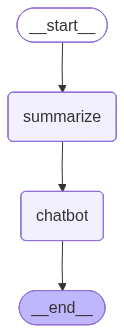

In [ ]:
from tero.graphs.chat import process_chat_message, langgraph_agent
from IPython.display import Image, display

try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass